# Data Analytics (DA)
## Module-End -5
### Module End  Assignment: Python For Data Analysis
# “Social Media Engagement Analytics”


### Assignment Tasks
* Task 1 — Data Import & Setup
* Import CSV using Pandas
* Check/convert data types
* Convert date columns to datetime


In [7]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# 1. Import CSV using Pandas
df = pd.read_csv('/content/drive/MyDrive/social_media_engagement_5000.csv')


# 2. Check initial data types and data structure
print("--- Initial Data Types ---")
print(df.dtypes)
df['posted_at'] = pd.to_datetime(df['posted_at'])
print("\n Date conversion complete. 'posted_at' column type:", df['posted_at'].dtype)
print(df.dtypes)



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- Initial Data Types ---
user_id               int64
age                 float64
gender               object
country              object
post_id               int64
post_type            object
post_category        object
likes               float64
comments            float64
shares              float64
watch_time_sec        int64
impression_count      int64
posted_at            object
follower_count        int64
is_verified            bool
device_type          object
sentiment            object
hashtags             object
engagement_rate     float64
dtype: object

 Date conversion complete. 'posted_at' column type: datetime64[ns]
user_id                      int64
age                        float64
gender                      object
country                     object
post_id                      int64
post_type                   object
post_category       

/tmp/ipykernel_13200/3070937502.py:16: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['posted_at'] = pd.to_datetime(df['posted_at'])


### Task 2 — Data Cleaning
* Cleaning Missing Data
* Detect missing values (isnull(), isna())
* Handle using: dropna(), fillna(), median/mode, forward/backward-fill
* Duplicate Handling- Identify & remove duplicates
#### Data Formatting
* Fix incorrect data types
* Standardize categories (e.g., gender labels)
* Correct unrealistic values in likes, comments, shares
* Feature Cleaning
* Extract hashtag count
* Clean sentiment labels


In [8]:
# --- 1. Cleaning Missing Data ---
print("Missing values before cleaning:\n", df.isnull().sum())

# Handle missing comments by filling with the median
median_comments = df['comments'].median()
df['comments'] = df['comments'].fillna(median_comments)

# Handle missing gender values by filling with 'Unknown'
df['gender'] = df['gender'].fillna('Unknown')

# --- 2. Duplicate Handling ---
print(f"\nDuplicates found: {df.duplicated().sum()}")
df = df.drop_duplicates().reset_index(drop=True)
print(f"Duplicates remaining: {df.duplicated().sum()}")

# --- 3. Data Formatting & Category Standardization ---
# Standardize gender labels
df['gender'] = df['gender'].replace({'M': 'Male', 'F': 'Female', 'male': 'Male', 'female': 'Female'})

# Standardize sentiment labels
df['sentiment'] = df['sentiment'].replace({'pos': 'Positive', 'neg': 'Negative'})

# Correct unrealistic negative values in likes, comments, shares
df['likes'] = df['likes'].apply(lambda x: 0 if x < 0 else x)
df['comments'] = df['comments'].apply(lambda x: 0 if x < 0 else x)
df['shares'] = df['shares'].apply(lambda x: 0 if x < 0 else x)

# --- 4. Feature Cleaning ---
# Extract hashtag count (handle string 'none' as 0)
df['hashtag_count'] = df['hashtags'].apply(lambda x: 0 if str(x).lower() == 'none' else len(str(x).split()))

print("\n✅ Data cleaning and standardization complete.")


Missing values before cleaning:
 user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64

Duplicates found: 0
Duplicates remaining: 0

✅ Data cleaning and standardization complete.


### Task 3 — Data Exploration using Pandas
* Perform the following:
* View dataset structure using head(), tail(), shape, and columns.
* Check data types and info with info() and dtypes.
* Generate summary statistics using describe().
* Analyze categorical distributions using value_counts(), unique(), and nunique().
* Create a correlation matrix for numeric fields.
* Use groupby() to summarize metrics (e.g., avg likes by post type, impressions by country).


In [15]:
# Dataset structures
print("--- Head ---")
print(df.head(2))
print("\n--- Tail ---")
print(df.tail(2))
print("\n--- Shape ---", df.shape)
print("\n--- Columns ---", df.columns.tolist())

# Info summary
print("\n--- Info ---")
df.info()

# Summary statistics
print("\n--- Summary Statistics ---")
print(df.describe())

# Categorical distributions
print("\n--- Post Type Distribution ---")
print(df['post_type'].value_counts())

print("\n--- Unique Countries ---")
print(df['country'].unique(), "Count:", df['country'].nunique())

# Correlation Matrix for numeric fields
numeric_cols = ['likes', 'comments', 'shares', 'impression_count', 'watch_time_sec', 'follower_count', 'age']
corr_matrix = df[numeric_cols].corr()
print("\n--- Correlation Matrix ---")
print(corr_matrix)

# Groupby metric summaries
print("\n--- Average Likes by Post Type ---")
print(df.groupby('post_type')['likes'].mean())

print("\n--- Total Impressions by Country ---")
print(df.groupby('country')['impression_count'].sum())


--- Head ---
   user_id   age  gender country  post_id post_type post_category    likes  \
0    25795  43.0  Female  Brazil   496713     image       fitness   7011.0   
1    10860  33.0    Male  Brazil   157326      reel          food  11750.0   

   comments  shares  watch_time_sec  impression_count  posted_at  \
0     354.0  1157.0            5726             44650 2022-12-17   
1    2606.0  1807.0            5947             80216 2023-06-02   

   follower_count  is_verified device_type sentiment               hashtags  \
0           81734        False      mobile  negative  #foodie #travel #love   
1            5963        False      mobile  negative               #fitness   

   engagement_rate  hashtag_count  
0         0.190862              3  
1         0.201493              1  

--- Tail ---
      user_id   age  gender  country  post_id post_type post_category  \
4998    29800  13.0  Female  Germany   785644     video       fitness   
4999    73400  54.0   Other    Japan   71

#### Task 4 — Data Wrangling
* Use merge, concat, or join if combining DataFrames.
* Create new fields such as engagement_score, log-transformed metrics (optional), and hashtag count.
* Perform groupby summaries by post_type, country, and sentiment.


In [18]:
# 1. Create engagement_score metric
# Weights: Likes = 1, Comments = 2, Shares = 3
df['engagement_score'] = df['likes'] + (df['comments'] * 2) + (df['shares'] * 3)

# 2. Create standard Engagement Rate metric (%)
df['engagement_rate'] = (df['engagement_score'] / df['impression_count']) * 100
# Handle edge case where impressions are zero or rate becomes infinitely large due to anomalies
df['engagement_rate'] = df['engagement_rate'].replace([np.inf, -np.inf], 0).fillna(0)

# 3. Perform Groupby Summaries
groupby_post = df.groupby('post_type')[['engagement_score', 'engagement_rate', 'likes']].mean()
groupby_country = df.groupby('country')[['engagement_score', 'engagement_rate', 'impression_count']].mean()
groupby_sentiment = df.groupby('sentiment')[['engagement_score', 'engagement_rate']].mean()

print("--- Wrangled Groupby Summary (Post Type) ---")
print(groupby_post)


--- Wrangled Groupby Summary (Post Type) ---
           engagement_score  engagement_rate         likes
post_type                                                 
image          16167.082203       108.604738  10104.848560
reel           15996.214167        97.277059  10035.341680
text           16063.869119       131.044646  10099.975124
video          16160.070934       135.322602  10190.972292


#### Task 5 — Statistical Analysis
* Compute descriptive stats for “likes, comments, shares, watch_time, engagement_rate, followers” columns: Mean, median, mode
* Standard deviation, variance Percentiles (Optional) Skewness and kurtosis


In [21]:
print(df.columns)
target_metrics = ['likes', 'comments', 'shares', 'watch_time_sec', 'engagement_rate', 'follower_count']

# Build comprehensive summary stats frame
stats_summary = pd.DataFrame()

stats_summary['Mean'] = df[target_metrics].mean()
stats_summary['Median'] = df[target_metrics].median()
stats_summary['Mode'] = df[target_metrics].mode().iloc[0]
stats_summary['Std Dev'] = df[target_metrics].std()
stats_summary['Variance'] = df[target_metrics].var()
stats_summary['25th Percentile'] = df[target_metrics].quantile(0.25)
stats_summary['75th Percentile'] = df[target_metrics].quantile(0.75)
stats_summary['Skewness'] = df[target_metrics].skew()
stats_summary['Kurtosis'] = df[target_metrics].kurt()

print("--- Detailed Statistical Summary Matrix ---")
print(stats_summary.round(2).to_string())


Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'hashtag_count', 'engagement_score'],
      dtype='object')
--- Detailed Statistical Summary Matrix ---
                      Mean     Median      Mode    Std Dev      Variance  25th Percentile  75th Percentile  Skewness  Kurtosis
likes             10107.04   10105.50    6486.0    5789.82  3.352201e+07          5068.50         15115.00     -0.01     -1.21
comments           1502.04    1497.00    1497.0     856.39  7.334095e+05           792.00          2235.25      0.00     -1.14
shares             1002.63    1012.00     138.0     579.62  3.359537e+05           498.00          1501.00     -0.01     -1.20
watch_time_sec     4014.50    4034.50     916.0    2308.10  5.327309e+06          2017.75          

#### Task 6 — Data Visualization (Min. 8 Plots Required)
####  Matplotlib
* Scatter: likes vs impressions
* Line: daily engagement trend
* Bar: posts by category
* Pie: gender distribution
* Histogram: age
* Box: engagement rate
### Seaborn
* Count plot: post type
* Bar plot: avg likes by category
* Violin: followers vs sentiment
* Pair plot: numeric features
* Heatmap: correlation matrix
* Swarm plot: engagement vs device
* Plotly (Interactive)
* Interactive line chart/bar chart/bubble/scatter chart


Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'hashtag_count', 'engagement_score'],
      dtype='object')


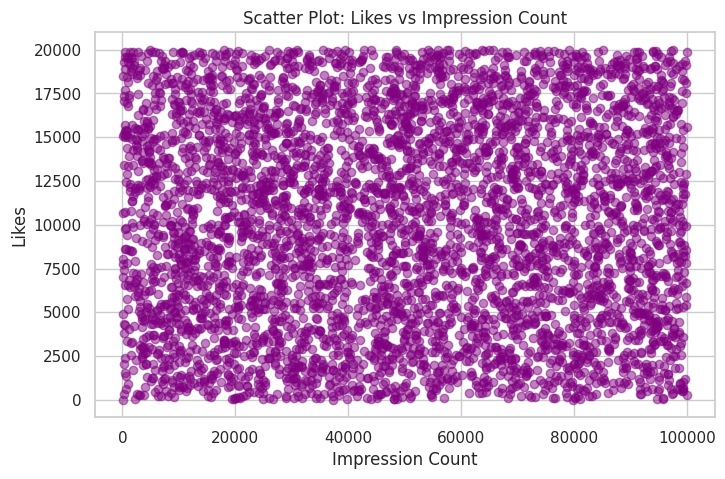

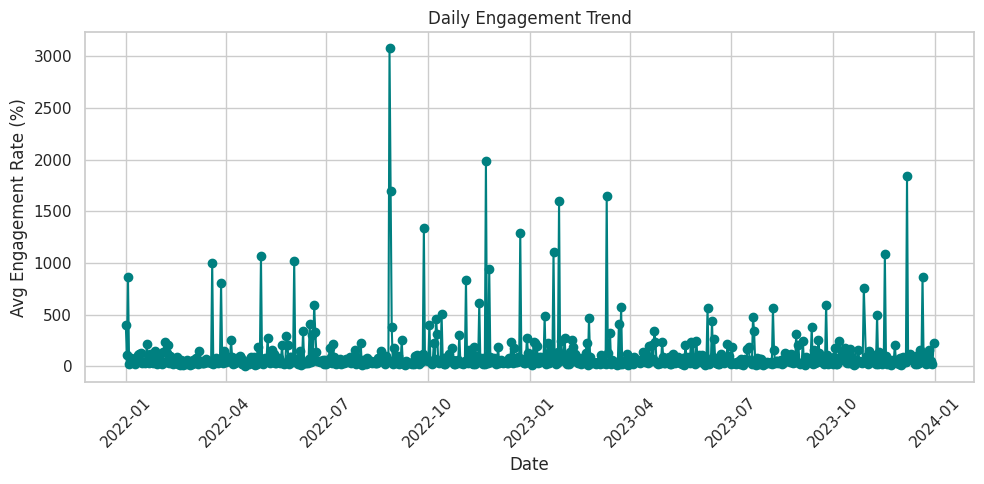

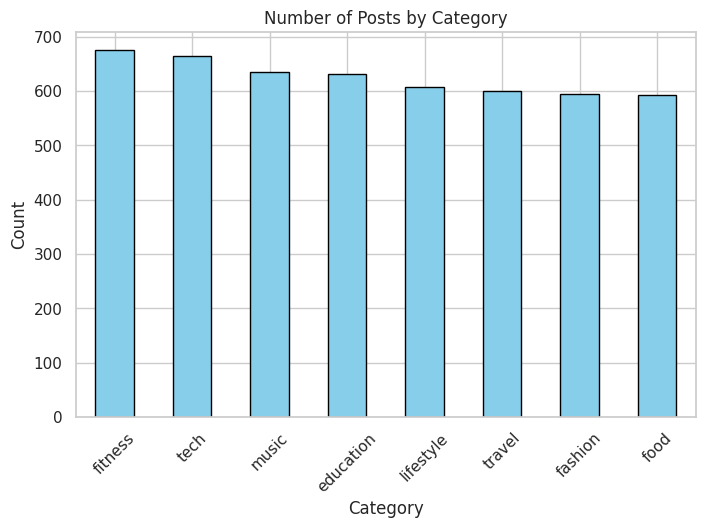

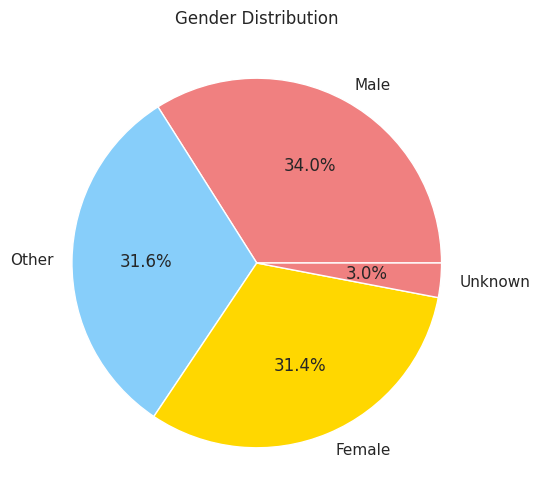

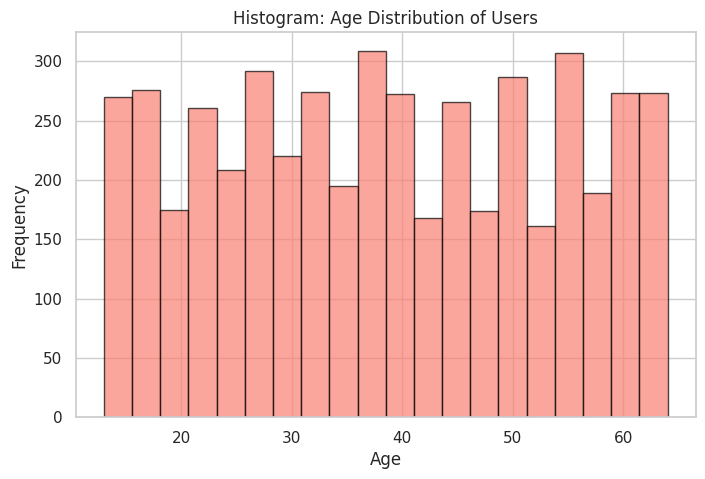

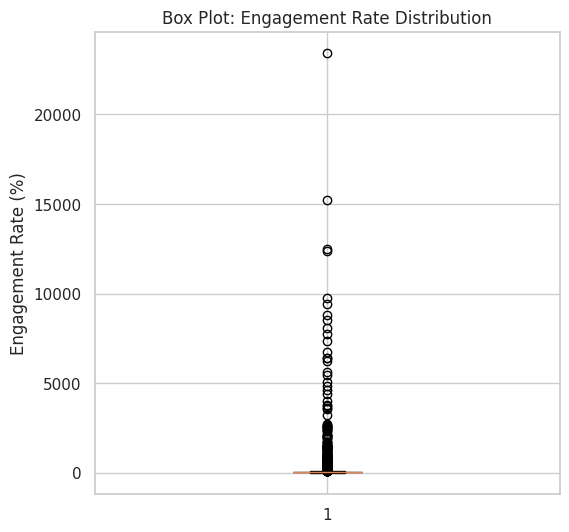

In [27]:
print(df.columns)
# 1. Scatter Plot: Likes vs Impression Count
plt.figure(figsize=(8, 5))
plt.scatter(df['impression_count'], df['likes'], alpha=0.5, color='purple')
plt.title('Scatter Plot: Likes vs Impression Count')
plt.xlabel('Impression Count')
plt.ylabel('Likes')
plt.show()

# 2. Line Plot: Daily Engagement Trend
daily_trend = df.groupby(df['posted_at'].dt.date)['engagement_rate'].mean().reset_index()
plt.figure(figsize=(10, 5))
plt.plot(daily_trend['posted_at'], daily_trend['engagement_rate'], marker='o', color='teal')
plt.title('Daily Engagement Trend')
plt.xlabel('Date')
plt.ylabel('Avg Engagement Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Bar Plot: Posts by Category
plt.figure(figsize=(8, 5))
df['post_category'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Number of Posts by Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# 4. Pie Chart: Gender Distribution
plt.figure(figsize=(6, 6))
df['gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['lightcoral', 'lightskyblue', 'gold'])
plt.title('Gender Distribution')
plt.ylabel('') # Hides the default column label
plt.show()
# 9. Histogram: Age Distribution
plt.figure(figsize=(8, 5))
plt.hist(df['age'], bins=20, color='salmon', edgecolor='black', alpha=0.7)
plt.title('Histogram: Age Distribution of Users')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# 10. Box Plot: Distribution of Engagement Rate
plt.figure(figsize=(6, 6))
plt.boxplot(df['engagement_rate'], patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.title('Box Plot: Engagement Rate Distribution')
plt.ylabel('Engagement Rate (%)')
plt.show()


In [30]:
# 5. Count Plot: Post Type
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='post_type', hue='post_type', palette='Set2', legend=False)
plt.title('Distribution of Post Types')
plt.xlabel('Post Type')
plt.ylabel('Count')
plt.show()

# 6. Heatmap: Correlation Matrix (Using your correct numeric columns)
numeric_cols = ['likes', 'comments', 'shares', 'impression_count', 'watch_time_sec', 'follower_count', 'age']
plt.figure(figsize=(9, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

# 7. Bar Plot: Average Likes by Category
plt.figure(figsize=(9, 5))
sns.barplot(data=df, x='post_category', y='likes', estimator='mean', errorbar=None, palette='viridis', hue='post_category', legend=False)
plt.title('Average Likes by Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# 8. Interactive Scatter Plot
fig = px.scatter(
    df,
    x="impression_count",
    y="likes",
    color="post_type",
    hover_data=['post_category', 'age'],
    title="Interactive Scatter: Likes vs Impression Count"
)
fig.show()

# 11. Pair Plot: Numeric Features (This may take a minute to render)
numeric_cols = ['likes', 'comments', 'shares', 'impression_count', 'age']
sns.pairplot(df[numeric_cols], diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pair Plot of Numeric Features', y=1.02)
plt.show()

# 12. Violin Plot: Followers vs Sentiment
# Note: Check if your column is named exactly 'sentiment' (e.g., Positive, Neutral, Negative)
if 'sentiment' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.violinplot(data=df, x='sentiment', y='follower_count', palette='Pastel1', hue='sentiment', legend=False)
    plt.title('Violin Plot: Follower Count by Sentiment')
    plt.xlabel('Sentiment')
    plt.ylabel('Follower Count')
    plt.show()

# 13. Swarm Plot: Engagement vs Device
# Note: If your dataset is very large (>1000 rows), a box/boxen plot is safer than a swarm plot to prevent crashes.
if 'device' in df.columns:
    plt.figure(figsize=(8, 5))
    # Using a sample of 200 rows if your dataset is massive so it renders fast
    df_sample = df.sample(200) if len(df) > 500 else df
    sns.swarmplot(data=df_sample, x='device', y='engagement_rate', palette='Set1', hue='device', legend=False)
    plt.title('Swarm Plot: Engagement Rate vs Device')
    plt.xlabel('Device Type')
    plt.ylabel('Engagement Rate (%)')
    plt.show()


Output hidden; open in https://colab.research.google.com to view.